In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import timedelta

# Define the last recorded dates
last_date_p1_p2 = pd.to_datetime("2019-11-08")  # Last date for P1 & P2 (weekly data)
last_date_p5 = pd.to_datetime("2019-08-30")  # Last date for P5 (weekly data)
last_date_p3_p4 = pd.to_datetime("2019-11-24")  # Last date for P3 & P4 (daily data)

# Load the complete dataset
df = pd.read_csv("../data/time_series_data.csv")


# Generate weekly date ranges for P1/P2 and P5 based on their respective end dates
df_p1_p2 = df[["t", "ProductP1", "ProductP2"]].copy()
df_p1_p2["date"] = [last_date_p1_p2 - timedelta(weeks=i) for i in reversed(range(100))]

df_p5 = df[["t", "ProductP5"]].copy()
df_p5["date"] = [last_date_p5 - timedelta(weeks=i) for i in reversed(range(100))]

# Find intersection of dates between P1/P2 and P5
common_dates = pd.merge(df_p1_p2, df_p5, on="date", how="inner").drop(columns=["t_y"])  # Drop duplicate t column

# Rename and reorder columns for clarity
df_p1_p2_p5 = common_dates.rename(columns={"t_x": "id"})[["id", "date", "ProductP1", "ProductP2", "ProductP5"]]

# Generate daily date range for P3/P4, P4 Price, and Temperature
p3_p4_df = df[["t", "ProductP3", "ProductP4", "price", "temperature"]].copy()
p3_p4_df["date"] = [last_date_p3_p4 - timedelta(days=i) for i in reversed(range(100))]

# Rename and reorder columns for clarity
df_p3_p4_price_temp = p3_p4_df.rename(columns={"t": "id"})[["id", "date", "ProductP3", "ProductP4", "price", "temperature"]]

# Aggregate P3/P4 data weekly (every Friday)
df_p3_p4_weekly = df_p3_p4_price_temp[df_p3_p4_price_temp["date"].dt.weekday == 4]  # Filter for Fridays
df_p3_p4_weekly = df_p3_p4_weekly.groupby("date").agg({
    "ProductP3": "sum",
    "ProductP4": "sum",
    "price": "last",  # Get last price on Friday
    "temperature": "last"  # Get last temperature on Friday
}).reset_index()

# Find the intersection of df_p3_p4_weekly and df_p1_p2_p5
df_p1_p2_p3_p4 = pd.merge(df_p1_p2, df_p3_p4_weekly, on="date", how="inner")

# Display the intersection dates
print("Common Dates Between P1/P2 and P5:")
print(df_p1_p2_p5)

# Display the separate dataframe for P3/P4, P4 Price, and Temperature
print("\nP3/P4, P4 Price, and Temperature DataFrame:")
print(df_p3_p4_price_temp)

# Display the intersection of df_p3_p4_weekly and df_p1_p2_p5
print("\nIntersection of Weekly P3/P4 and P1/P2/P5 Data:")
print(df_p1_p2_p3_p4)


Common Dates Between P1/P2 and P5:
    id       date  ProductP1  ProductP2  ProductP5
0    1 2017-12-15        197         66          1
1    2 2017-12-22        153         44          0
2    3 2017-12-29        128         55          5
3    4 2018-01-05        133         57          0
4    5 2018-01-12        120         47          0
..  ..        ...        ...        ...        ...
85  86 2019-08-02        130        301          0
86  87 2019-08-09        158        202          0
87  88 2019-08-16        179        267          4
88  89 2019-08-23        158        205          0
89  90 2019-08-30        162        204          0

[90 rows x 5 columns]

P3/P4, P4 Price, and Temperature DataFrame:
     id       date  ProductP3  ProductP4  price  temperature
0     1 2019-08-17        266        113      1           18
1     2 2019-08-18        264         74      2           21
2     3 2019-08-19        317        116      1           19
3     4 2019-08-20        390         70 

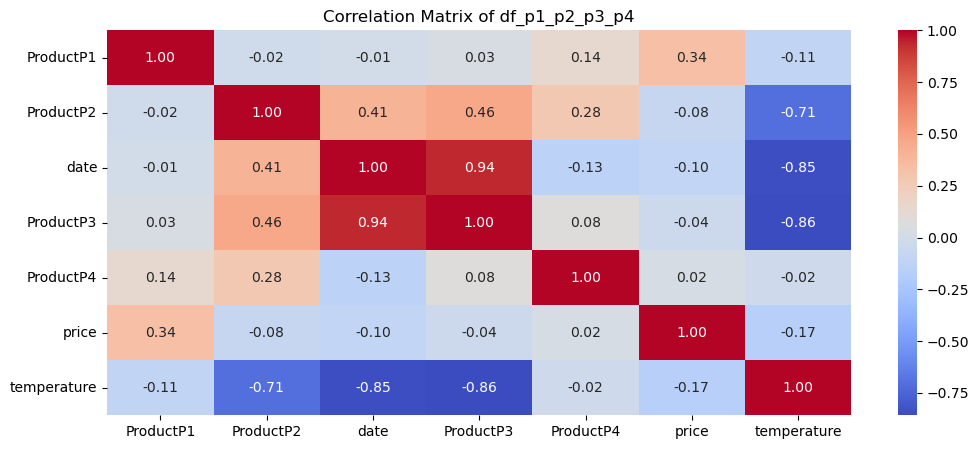

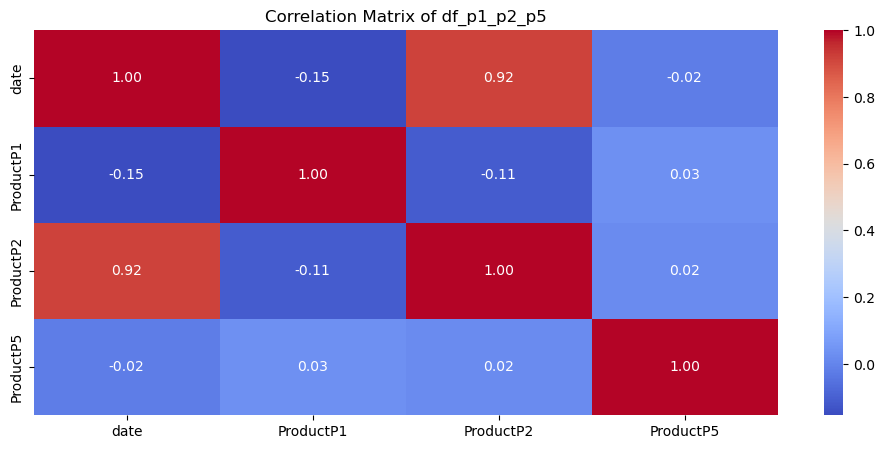

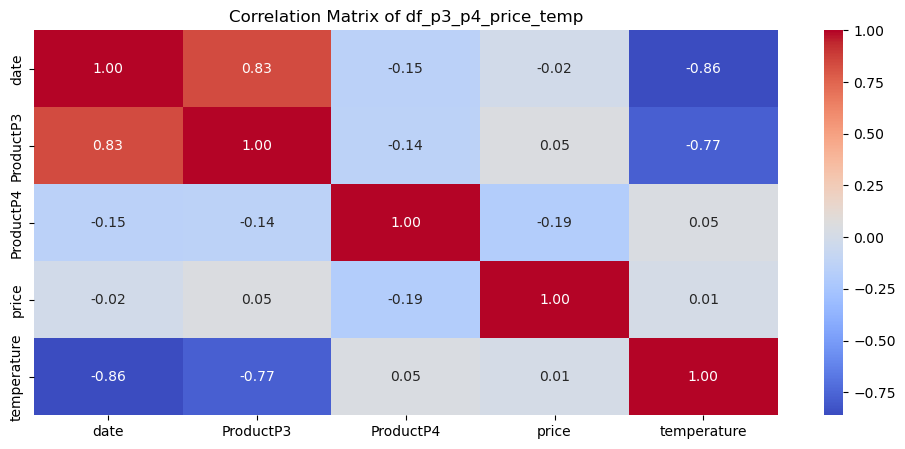

In [69]:
# Plot correlation heatmaps excluding 'id' column
plt.figure(figsize=(12, 5))
sns.heatmap(df_p1_p2_p3_p4.drop(columns=["t"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of df_p1_p2_p3_p4")
plt.show()

plt.figure(figsize=(12, 5))
sns.heatmap(df_p1_p2_p5.drop(columns=["id"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of df_p1_p2_p5")
plt.show()

plt.figure(figsize=(12, 5))
sns.heatmap(df_p3_p4_price_temp.drop(columns=["id"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of df_p3_p4_price_temp")
plt.show()

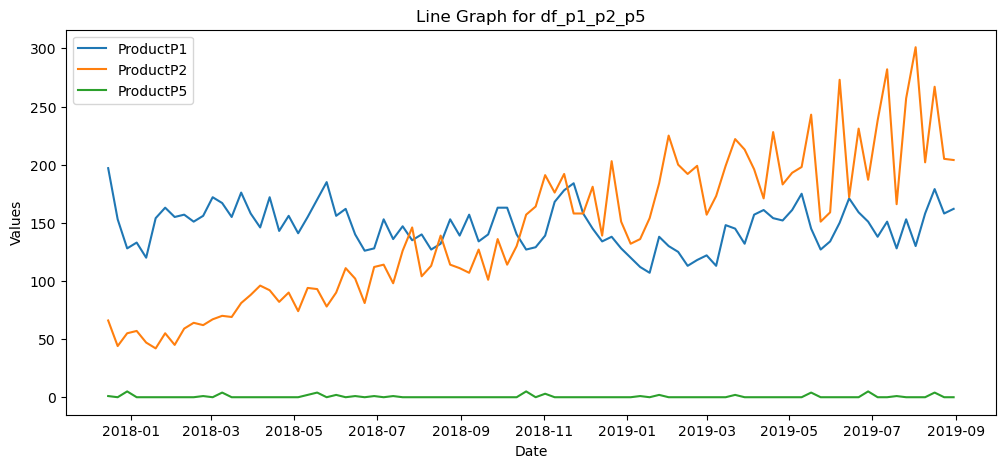

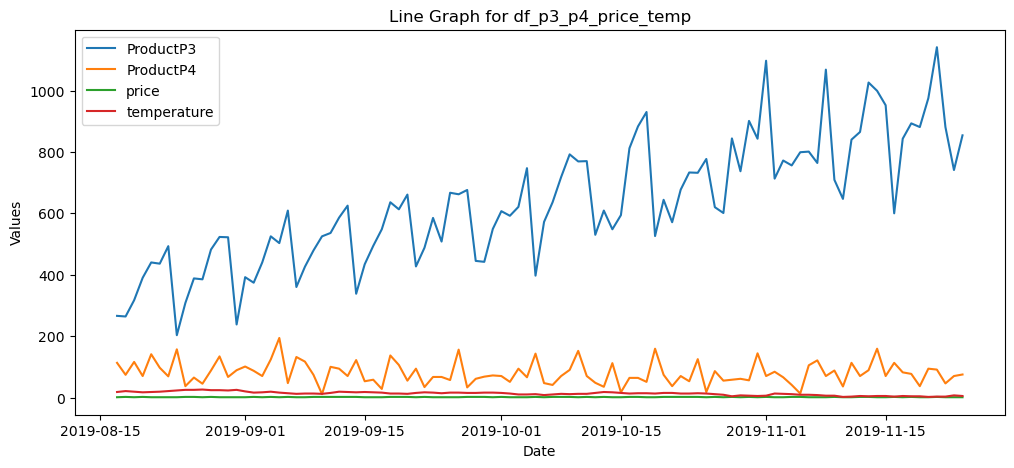

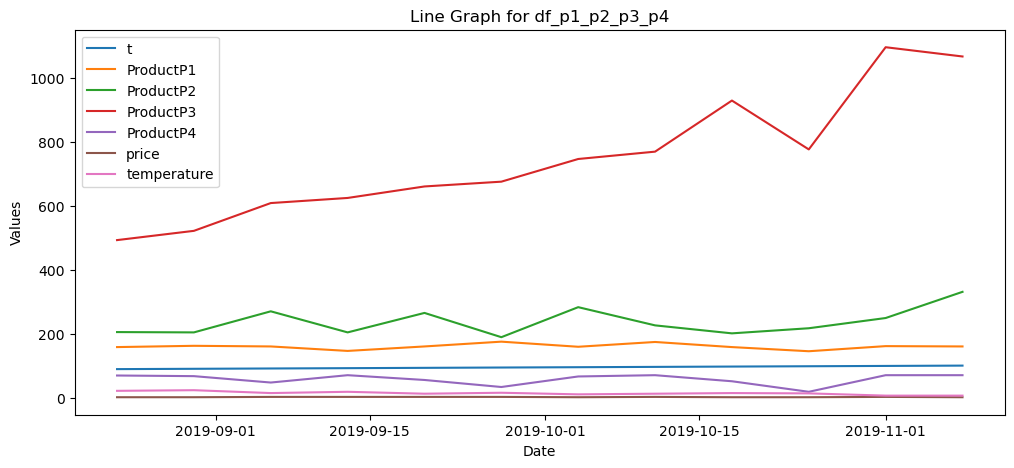

Common Dates Between P1/P2 and P5:
    id       date  ProductP1  ProductP2  ProductP5
0    1 2017-12-15        197         66          1
1    2 2017-12-22        153         44          0
2    3 2017-12-29        128         55          5
3    4 2018-01-05        133         57          0
4    5 2018-01-12        120         47          0
..  ..        ...        ...        ...        ...
85  86 2019-08-02        130        301          0
86  87 2019-08-09        158        202          0
87  88 2019-08-16        179        267          4
88  89 2019-08-23        158        205          0
89  90 2019-08-30        162        204          0

[90 rows x 5 columns]

P3/P4, P4 Price, and Temperature DataFrame:
     id       date  ProductP3  ProductP4  price  temperature
0     1 2019-08-17        266        113      1           18
1     2 2019-08-18        264         74      2           21
2     3 2019-08-19        317        116      1           19
3     4 2019-08-20        390         70 

In [71]:
# Plot line graphs for each dataframe
def plot_line_graph(df, title):
    plt.figure(figsize=(12, 5))
    for column in df.columns:
        if column not in ["id", "date"]:
            plt.plot(df["date"], df[column], label=column)
    plt.xlabel("Date")
    plt.ylabel("Values")
    plt.title(title)
    plt.legend()
    plt.show()

plot_line_graph(df_p1_p2_p5, "Line Graph for df_p1_p2_p5")
plot_line_graph(df_p3_p4_price_temp, "Line Graph for df_p3_p4_price_temp")
plot_line_graph(df_p1_p2_p3_p4, "Line Graph for df_p1_p2_p3_p4")

# Display the intersection dates
print("Common Dates Between P1/P2 and P5:")
print(df_p1_p2_p5)

# Display the separate dataframe for P3/P4, P4 Price, and Temperature
print("\nP3/P4, P4 Price, and Temperature DataFrame:")
print(df_p3_p4_price_temp)

# Display the weekly aggregated dataframe for P3/P4
print("\nWeekly Aggregated P3/P4 Data (Every Friday):")
print(df_p3_p4_weekly)

# Display the intersection of df_p3_p4_weekly and df_p1_p2_p5
print("\nIntersection of Weekly P3/P4 and P1/P2 Data:")
print(df_p1_p2_p3_p4)